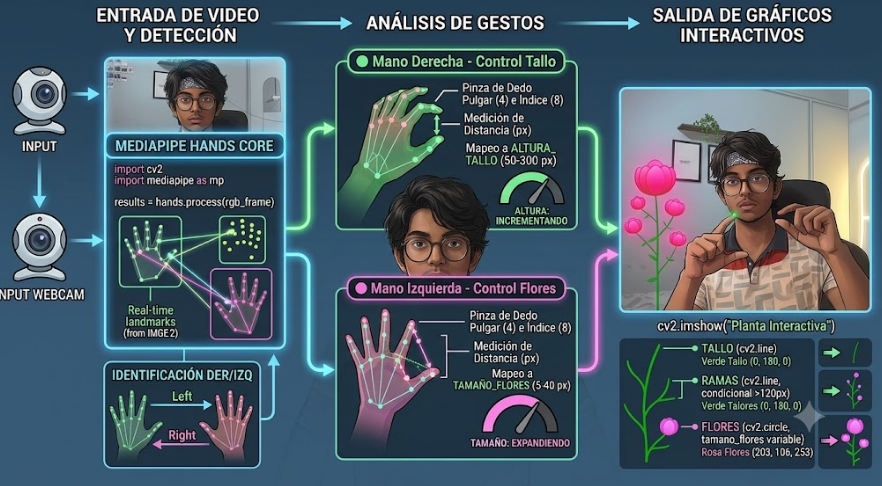

In [ ]:
import sys
print(sys.version)

In [ ]:
# Instalar las librerias necesarias:
# - opencv-python: Libreria para captura de video y procesamiento de imagenes
# - mediapipe: Framework de Google para deteccion de manos y gestos
pip install opencv-python mediapipe

In [ ]:
# Desinstalar mediapipe por si hay conflictos de versiones
!pip uninstall mediapipe -y

In [ ]:
# Instalar una version especifica de mediapipe (0.10.14) para asegurar compatibilidad
pip install mediapipe==0.10.14

In [ ]:
# Verificar que mediapipe se haya instalado correctamente
# Se imprime la version y se verifica que exista el modulo 'solutions'
import mediapipe as mp

print(mp.__version__)
print(hasattr(mp, "solutions"))

In [ ]:
# ====================================================================
# PROGRAMA: PLANTA INTERACTIVA CON CONTROL DE GESTOS
# 
# Descripcion:
# Este programa utiliza la camara web y MediaPipe Hands para detectar
# la posicion de las manos del usuario. A traves de la distancia entre
# el pulgar y el indice (gesto de pinza), se controla una planta virtual
# que crece en la pantalla.
#
# Controles:
# - Mano Derecha (etiquetada como 'Left' por el efecto espejo):
#   Abrir/cerrar los dedos controla la ALTURA del tallo.
# - Mano Izquierda (etiquetada como 'Right' por el efecto espejo):
#   Abrir/cerrar los dedos controla el TAMANO de las flores.
#
# Librerias utilizadas:
# - OpenCV (cv2): Captura de video, procesamiento de imagenes y dibujo.
# - MediaPipe (mp): Deteccion de landmarks de la mano en tiempo real.
# - math: Calculo de distancias euclidianas entre puntos.
# ====================================================================
import cv2
import mediapipe as mp
import math

# --- INICIALIZACION DE MEDIAPIPE ---
# mp_hands: Modulo de deteccion de manos de MediaPipe.
# hands: Configuracion del detector (max 2 manos, confianza minima 70%).
# mp_draw: Utilidad para dibujar el esqueleto de la mano sobre la imagen.
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.7)
mp_draw = mp.solutions.drawing_utils

# --- INICIALIZACION DE LA CAMARA ---
# Se abre la camara por defecto (indice 0) para capturar video en tiempo real.
cap = cv2.VideoCapture(0)

# --- VARIABLES DE CONTROL DE LA PLANTA ---
# altura_tallo: Altura inicial del tallo en pixeles (controlada por mano derecha).
# tamano_flores: Radio inicial de las flores en pixeles (controlado por mano izquierda).
altura_tallo = 80
tamano_flores = 30

def calcular_distancia(p1, p2, width, height):
    """
    Calcula la distancia euclidiana en pixeles entre dos landmarks de la mano.
    
    Parametros:
        p1, p2: Landmarks de MediaPipe (contienen coordenadas normalizadas x, y).
        width, height: Dimensiones del frame en pixeles.
    
    Retorno:
        Distancia en pixeles entre los dos puntos.
    """
    x1, y1 = int(p1.x * width), int(p1.y * height)
    x2, y2 = int(p2.x * width), int(p2.y * height)
    return math.hypot(x2 - x1, y2 - y1)

# --- BUCLE PRINCIPAL DE PROCESAMIENTO DE VIDEO ---
# Se ejecuta frame por frame hasta que el usuario presione ESC.
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Voltear la imagen horizontalmente para crear un efecto espejo natural.
    # Esto hace que el movimiento de la mano se sienta mas intuitivo.
    frame = cv2.flip(frame, 1)
    height, width, _ = frame.shape

    # MediaPipe trabaja con imagenes en formato RGB, pero OpenCV usa BGR.
    # Se convierte el frame de BGR a RGB antes de procesarlo.
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb_frame)

    # Si se detectan una o dos manos en el frame...
    if results.multi_hand_landmarks and results.multi_handedness:
        for hand_landmarks, hand_info in zip(results.multi_hand_landmarks, results.multi_handedness):
            # MediaPipe etiqueta las manos como 'Left' o 'Right'.
            # Debido al efecto espejo (flip horizontal), la mano derecha
            # fisica aparece como 'Left' en la imagen y viceversa.
            lado_mano = hand_info.classification[0].label
            
            # Los landmarks 4 y 8 corresponden a la punta del pulgar y del indice.
            # Estos dos puntos se usan para medir la apertura de la pinza.
            pulgar = hand_landmarks.landmark[4]
            indice = hand_landmarks.landmark[8]
            
            # Se calcula la distancia entre pulgar e indice.
            # Cuanto mas separados esten, mayor sera el valor de control.
            distancia = calcular_distancia(pulgar, indice, width, height)

            # Dibujar circulos verdes en las puntas de los dedos y una linea
            # amarilla entre ellos para visualizar la distancia de pinza.
            px, py = int(pulgar.x * width), int(pulgar.y * height)
            ix, iy = int(indice.x * width), int(indice.y * height)
            cv2.circle(frame, (px, py), 8, (0, 255, 0), cv2.FILLED)
            cv2.circle(frame, (ix, iy), 8, (0, 255, 0), cv2.FILLED)
            cv2.line(frame, (px, py), (ix, iy), (0, 255, 255), 2)

            # Asignacion de roles segun la mano detectada.
            # Nota: Por el espejo, 'Left' en pantalla corresponde a la mano
            # derecha real del usuario, y 'Right' a la mano izquierda real.
            if lado_mano == "Left":  # Mano Derecha del usuario
                # La distancia se mapea a un rango de 50 a 300 pixeles.
                # Factor 1.5 amplifica el movimiento para mayor sensibilidad.
                altura_tallo = int(max(50, min(distancia * 1.5, 300)))
                cv2.putText(frame, "Mano Derecha: Crecer Tallo", (ix, iy - 20), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
            elif lado_mano == "Right":  # Mano Izquierda del usuario
                # La distancia se mapea a un rango de 5 a 40 pixeles.
                # Factor reducido (0.2) porque las flores necesitan menos rango.
                tamano_flores = int(max(5, min(distancia * 0.2, 40)))
                cv2.putText(frame, "Mano Izquierda: Flores", (ix, iy - 20), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # --- DIBUJO DE LA PLANTA INTERACTIVA ---
    # La planta se dibuja en la esquina inferior izquierda de la pantalla.
    # Su posicion base es fija y el tallo crece hacia arriba.
    base_x, base_y = 150, height - 20

    # 1. TALLO: Linea vertical verde cuya longitud depende de 'altura_tallo'.
    #    A mayor distancia entre dedos, mas crece el tallo.
    tope_tallo_y = base_y - altura_tallo
    cv2.line(frame, (base_x, base_y), (base_x, tope_tallo_y), (0, 180, 0), 6)

    # 2. RAMAS SECUNDARIAS: Aparecen solo cuando el tallo supera 120 pixeles.
    #    Cada rama tiene una flor pequenia en su extremo.
    if altura_tallo > 120:
        cv2.line(frame, (base_x, tope_tallo_y + 60), (base_x - 40, tope_tallo_y + 40), (0, 180, 0), 4)
        cv2.circle(frame, (base_x - 40, tope_tallo_y + 40), tamano_flores // 2, (0, 0, 255), cv2.FILLED)
        
        cv2.line(frame, (base_x, tope_tallo_y + 30), (base_x + 40, tope_tallo_y + 10), (0, 180, 0), 4)
        cv2.circle(frame, (base_x + 40, tope_tallo_y + 10), tamano_flores // 2, (0, 0, 255), cv2.FILLED)

    # 3. FLOR PRINCIPAL: Circulo en el tope del tallo cuyo radio cambia
    #    segun el valor de 'tamano_flores'. Si es suficientemente grande,
    #    se dibujan petalos alrededor para darle forma de rosa.
    cv2.circle(frame, (base_x, tope_tallo_y), tamano_flores, (203, 106, 253), cv2.FILLED)
    if tamano_flores > 8:
        cv2.circle(frame, (base_x - tamano_flores, tope_tallo_y), tamano_flores // 2, (147, 20, 255), cv2.FILLED)
        cv2.circle(frame, (base_x + tamano_flores, tope_tallo_y), tamano_flores // 2, (147, 20, 255), cv2.FILLED)
        cv2.circle(frame, (base_x, tope_tallo_y - tamano_flores), tamano_flores // 2, (147, 20, 255), cv2.FILLED)

    # Mostrar el frame resultante en una ventana.
    cv2.imshow("Planta Interactiva", frame)

    # Salir del programa si el usuario presiona ESC (codigo 27) o cierra la ventana.
    if cv2.waitKey(1) & 0xFF == 27 or cv2.getWindowProperty("Planta Interactiva", cv2.WND_PROP_VISIBLE) < 1:
        break

# --- LIMPIEZA DE RECURSOS ---
# Liberar la camara y cerrar todas las ventanas de OpenCV.
cap.release()
cv2.destroyAllWindows()